In [1]:
# Creating the Virtual Environment For us to get started with out project
# !pip list -> shows all the packages that are currently present in the directory.

# These are the packages that we will need.

import sys
print(sys.executable)
!{sys.executable} -m pip install datasets huggingface_hub ipywidgets

# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
# pip install transformers datasets scikit-learn pandas numpy
# pip install shap lime matplotlib seaborn
# pip install fastapi uvicorn python-multipart
# pip install jupyter notebook

C:\Users\Retro\AppData\Local\Programs\Python\Python312\python.exe



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# My pc was missing tow packages so I had to install them here

try:
    !pip install shap lime
    print("Installed Successfully or requirement already present")
except error as e:
    print(f"Ran onto this error{ e }")

Installed Successfully or requirement already present


In [3]:
# Alright since all the dependencies have been installed, we can proceed with out next steps,
# Just to confirm I am using my GPU and so the training will be significantly faster, if you are using a cpu then it will be a bit slower for you.


In [4]:
# Here We are importing the entire LIAR dataset, this might take a while.
# I have included some extra chunks of code so that we can see in real-time how far we have progressed.

from datasets import load_dataset
import time

start = time.time()

dataset = load_dataset(
    "ucsbnlp/liar",
    revision="refs/convert/parquet"
)

print(f"Loaded in {time.time() - start:.2f}s")
print(dataset)
print(dataset["train"][0])

Loaded in 1.37s
DatasetDict({
    train: Dataset({
        features: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context'],
        num_rows: 10269
    })
    validation: Dataset({
        features: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context'],
        num_rows: 1284
    })
    test: Dataset({
        features: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context'],
        num_rows: 1283
    })
})
{'id': '2635.json', 'label': 0, 'statement': 'Says the Annies List political group supports third-trimester ab

In [5]:
# Time to do the label mapping

# Label mapping (numeric in this dataset):
# 0 = super fake → FAKE
# 1 = false → FAKE  
# 2 = barely-true → DROP
# 3 = half-true → DROP
# 4 = mostly-true → REAL
# 5 = true → REAL

def binarize(example):
    mapping = {0: 0, 1: 0, 2: None, 3: None, 4: 1, 5: 1}
    example["binary_label"] = mapping[example["label"]]
    return example

# Apply to all splits
dataset = dataset.map(binarize)

# Drop the ambiguous middle (barely-true + half-true)
dataset = dataset.filter(lambda x: x["binary_label"] is not None)

# Verify
print(dataset)
print("Train label distribution:", dataset["train"]["binary_label"].count(0), "fake |", dataset["train"]["binary_label"].count(1), "real")

DatasetDict({
    train: Dataset({
        features: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'binary_label'],
        num_rows: 6620
    })
    validation: Dataset({
        features: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'binary_label'],
        num_rows: 864
    })
    test: Dataset({
        features: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'binary_label'],
        num_rows: 823
    })
})
Train label distribution: 4121 fake | 2499 real


In [6]:
# Since there were some imbalances in the true/fake, we decided to oversample the real ones as well.

from datasets import concatenate_datasets

fake_samples = dataset["train"].filter(lambda x: x["binary_label"] == 0)
real_samples = dataset["train"].filter(lambda x: x["binary_label"] == 1)

print(f"Before: {len(fake_samples)} fake | {len(real_samples)} real")

# How many times to repeat + how many extra needed
target = len(fake_samples)  # 4121
repeats = target // len(real_samples)       # full copies
remainder = target % len(real_samples)      # leftover

# Build oversampled real
real_oversampled = concatenate_datasets(
    [real_samples] * repeats + 
    [real_samples.shuffle(seed=42).select(range(remainder))]
)

# Recombination and shuffleling
balanced_train = concatenate_datasets([fake_samples, real_oversampled]).shuffle(seed=42)

print(f"After: {balanced_train['binary_label'].count(0)} fake | {balanced_train['binary_label'].count(1)} real")
print(f"Total training samples: {len(balanced_train)}")

Before: 4121 fake | 2499 real
After: 4121 fake | 4121 real
Total training samples: 8242


## 📊 Evaluation Metrics

### Confusion Matrix Building Blocks

| | Predicted FAKE | Predicted REAL |
|---|---|---|
| **Actual FAKE** | ✅ True Positive (TP) — correctly caught fake | ❌ False Negative (FN) — missed misinformation |
| **Actual REAL** | ❌ False Positive (FP) — wrongly accused real | ✅ True Negative (TN) — correctly passed real |

---

### Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
> **Limitation:** misleading on imbalanced datasets. A model predicting FAKE always would score ~62% before oversampling. Always pair with F1.

---

### Precision
$$\text{Precision} = \frac{TP}{TP + FP}$$
> Of everything flagged as FAKE, how many were actually FAKE?  
> **Low precision** = model wrongly accuses real news → credibility problem.

---

### Recall (Sensitivity)
$$\text{Recall} = \frac{TP}{TP + FN}$$
> Of all actually FAKE articles, how many did the model catch?  
> **Low recall** = misinformation slips through undetected → safety problem.

---

### F1-Score *(primary metric)*
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
> Harmonic mean of precision and recall. A model with 90% precision and 10% recall gets F1 = **0.18**, not 0.50. Reported as **macro average** across both classes.

---

### ROC Curve & AUC

| Term | Formula | Meaning |
|---|---|---|
| TPR (Sensitivity) | TP / (TP + FN) | Y-axis — same as recall |
| FPR | FP / (FP + TN) | X-axis — false alarm rate |
| AUC | Area under ROC | 0.5 = random, 1.0 = perfect |
| Optimal threshold | argmax(TPR − FPR) | Youden's J statistic |

> **Note:** All metrics reported as macro-averaged across FAKE and REAL classes.

=== Validation Results ===
              precision    recall  f1-score   support

        FAKE       0.61      0.60      0.60       511
        REAL       0.44      0.45      0.45       353

    accuracy                           0.54       864
   macro avg       0.52      0.53      0.52       864
weighted avg       0.54      0.54      0.54       864



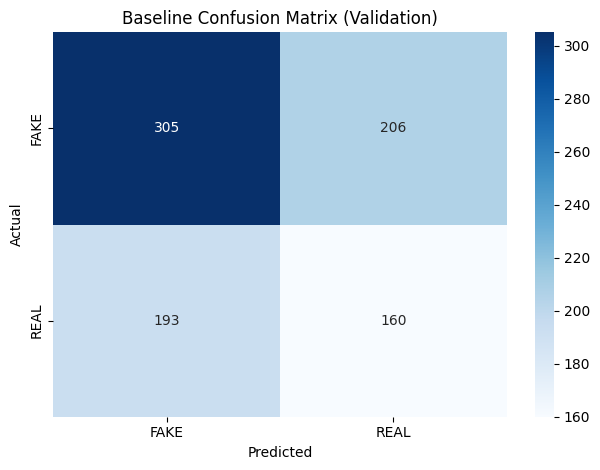

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Extract text and labels
X_train = balanced_train["statement"]
y_train = balanced_train["binary_label"]

X_val = dataset["validation"]["statement"]
y_val = dataset["validation"]["binary_label"]

X_test = dataset["test"]["statement"]
y_test = dataset["test"]["binary_label"]

# Vectorize
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

# Train
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, y_train)

# Evaluate on validation
val_preds = clf.predict(X_val_tfidf)
print("=== Validation Results ===")
print(classification_report(y_val, val_preds, target_names=["FAKE", "REAL"]))

# Confusion matrix
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["FAKE", "REAL"],
            yticklabels=["FAKE", "REAL"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Confusion Matrix (Validation)")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=250)
plt.show()

In [8]:
# So This is sort of like what the Results are telling us: 

"""

Predicted FAKE    Predicted REAL
Actual FAKE     TP = 305          FP = 206
Actual REAL     FN = 193          TN = 160


TP 305 — correctly caught 305 fake articles
FP 206 — wrongly flagged 206 real articles as fake
FN 193 — missed 193 fake articles, let them through as real
TN 160 — correctly passed 160 real articles

"""

'\n\nPredicted FAKE    Predicted REAL\nActual FAKE     TP = 305          FP = 206\nActual REAL     FN = 193          TN = 160\n\n\nTP 305 — correctly caught 305 fake articles\nFP 206 — wrongly flagged 206 real articles as fake\nFN 193 — missed 193 fake articles, let them through as real\nTN 160 — correctly passed 160 real articles\n\n'

  Pearson Correlation with binary_label
  pants_on_fire_counts         +0.1039  ███
  false_counts                 +0.0044  
  barely_true_counts           -0.0058  
  half_true_counts             -0.0558  █
  mostly_true_counts           -0.0562  █


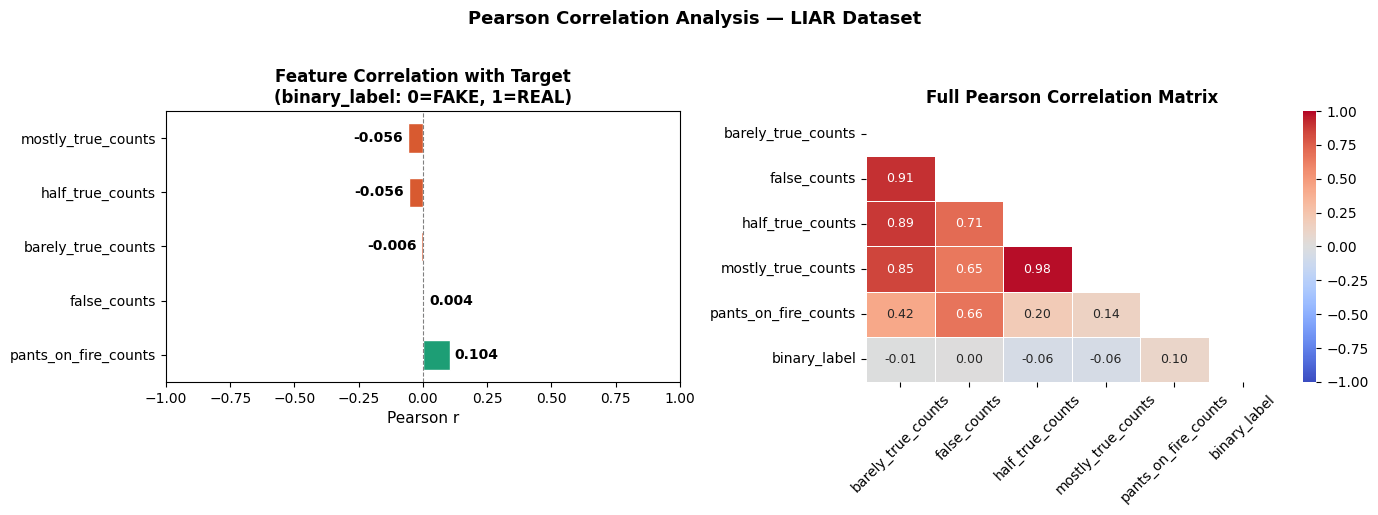

In [9]:
# Infamous Pearson Coorelation 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Convert to DataFrame ───────────────────────────────────
numeric_cols = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "binary_label"
]

df = pd.DataFrame(balanced_train.select_columns(numeric_cols).to_dict())

# ── Compute Pearson Correlation ────────────────────────────
corr_matrix = df.corr(method="pearson")

# Correlation of each feature against binary_label only
target_corr = (
    corr_matrix["binary_label"]
    .drop("binary_label")
    .sort_values(ascending=False)
)

print("=" * 45)
print("  Pearson Correlation with binary_label")
print("=" * 45)
for col, val in target_corr.items():
    bar = "█" * int(abs(val) * 30)
    direction = "+" if val >= 0 else "-"
    print(f"  {col:<28} {direction}{abs(val):.4f}  {bar}")
print("=" * 45)

# ── Plot 1: Target Correlation Bar Chart ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#1D9E75" if v > 0 else "#D85A30" for v in target_corr.values]
bars = axes[0].barh(target_corr.index, target_corr.values,
                    color=colors, edgecolor="white", height=0.55)
axes[0].axvline(x=0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Pearson r", fontsize=11)
axes[0].set_title("Feature Correlation with Target\n(binary_label: 0=FAKE, 1=REAL)",
                   fontsize=12, fontweight="bold")
axes[0].set_xlim(-1, 1)

for bar, val in zip(bars, target_corr.values):
    axes[0].text(
        val + (0.02 if val >= 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right",
        fontsize=10, fontweight="bold"
    )

# ── Plot 2: Full Correlation Heatmap ──────────────────────
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=axes[1],
    linewidths=0.5,
    annot_kws={"size": 9}
)
axes[1].set_title("Full Pearson Correlation Matrix",
                   fontsize=12, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle("Pearson Correlation Analysis — LIAR Dataset",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("pearson_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

=== Baseline Metrics (Validation) ===
Accuracy  : 0.5382
Precision : 0.5248
Recall    : 0.5251
F1 (macro): 0.5248

=== Per-Class Breakdown ===
              precision    recall  f1-score   support

        FAKE       0.61      0.60      0.60       511
        REAL       0.44      0.45      0.45       353

    accuracy                           0.54       864
   macro avg       0.52      0.53      0.52       864
weighted avg       0.54      0.54      0.54       864



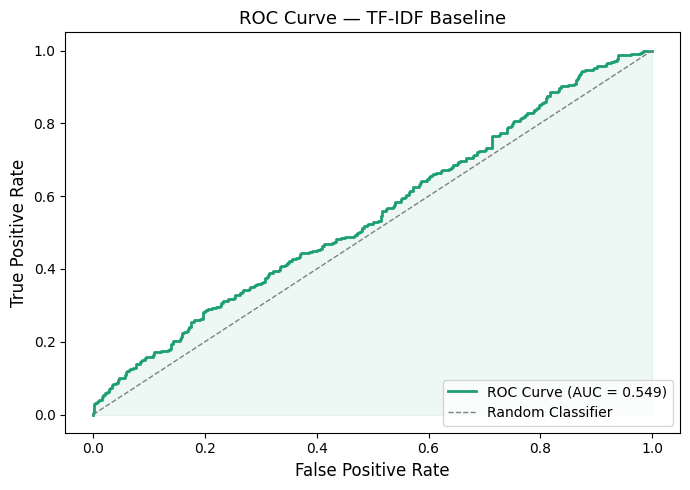


Optimal threshold (Youden's J): 0.573
AUC: 0.5488


In [10]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_curve, auc
)
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities for ROC (probability of being REAL = class 1)
val_probs = clf.predict_proba(X_val_tfidf)[:, 1]
val_preds = clf.predict(X_val_tfidf)

# ── Core Metrics ──────────────────────────────────────────
accuracy  = accuracy_score(y_val, val_preds)
precision = precision_score(y_val, val_preds, average="macro")
recall    = recall_score(y_val, val_preds, average="macro")
f1        = f1_score(y_val, val_preds, average="macro")

print("=== Baseline Metrics (Validation) ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 (macro): {f1:.4f}")

# ── Per-Class Breakdown ───────────────────────────────────
print("\n=== Per-Class Breakdown ===")
print(classification_report(y_val, val_preds, target_names=["FAKE", "REAL"]))

# ── ROC Curve ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_val, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#1D9E75", lw=2,
         label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1,
         linestyle="--", label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.08, color="#1D9E75")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — TF-IDF Baseline", fontsize=13)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("baseline_roc_curve.png", dpi=250)
plt.show()

# ── Optimal Threshold ─────────────────────────────────────
# Youden's J statistic — finds the threshold that best balances TPR and FPR
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.3f}")
print(f"AUC: {roc_auc:.4f}")

In [11]:
## Now We are enhancing the features a lot more so that the metrics get higher and our model becomes more useful

# 1. Add more features beyond just the statement text
#    The dataset has speaker, party, context — using them, 
# not necessarily always effective it's best practice to run the pearson corr function first to check the relevancy

def combine_features(example):
    example["rich_text"] = (
        f"{example['statement']} "
        f"speaker:{example['speaker']} "
        f"party:{example['party_affiliation']} "
        f"context:{example['context']}"
    )
    return example

dataset = dataset.map(combine_features)
balanced_train = balanced_train.map(combine_features)

# Then use rich_text instead of statement in your vectorizer
X_train = balanced_train["rich_text"]

In [12]:
# 2. Tune the vectorizer — capture more signal
vectorizer = TfidfVectorizer(
    max_features=50000,       # was 10000
    ngram_range=(1, 3),       # was (1,2) — adds trigrams
    sublinear_tf=True,        # log scale term frequency
    min_df=2,                 # ignore ultra-rare terms
    analyzer='char_wb'        # character n-grams catch morphology
)

       LinearSVC Baseline (Validation)
  Accuracy       : 0.5509
  Precision      : 0.5316
  Recall         : 0.5310
  F1 (macro)     : 0.5310
  AUC            : 0.5352
  Optimal thresh : 0.485

--- Per-Class Report ---
              precision    recall  f1-score   support

        FAKE       0.62      0.64      0.63       511
        REAL       0.45      0.42      0.43       353

    accuracy                           0.55       864
   macro avg       0.53      0.53      0.53       864
weighted avg       0.55      0.55      0.55       864



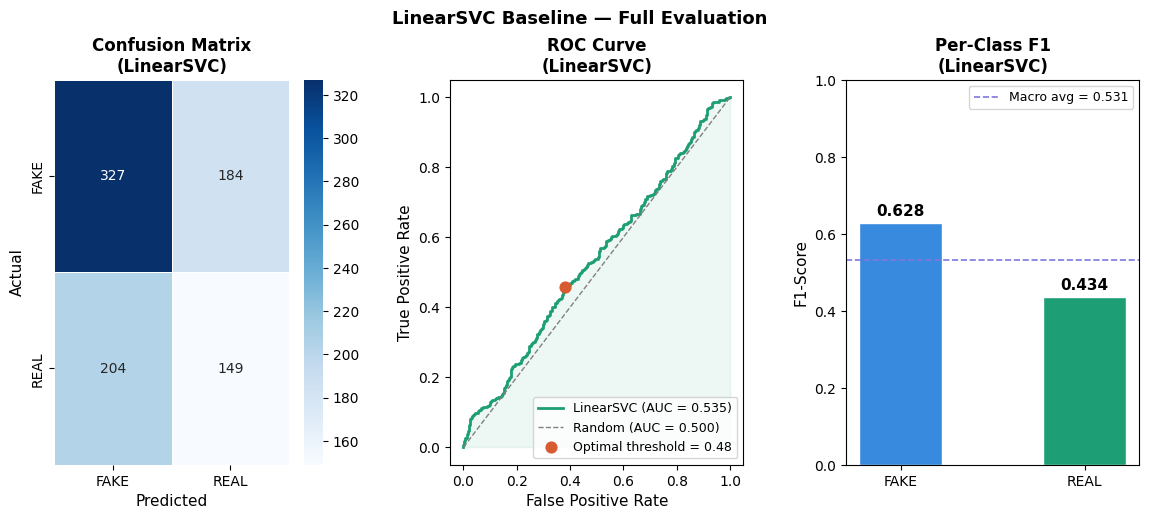


Plot saved → svc_baseline_evaluation.png


In [13]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_curve, auc,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ── Train LinearSVC (wrapped for probability output) ──────
# LinearSVC doesn't have predict_proba natively
# CalibratedClassifierCV adds it via cross-validation
svc = LinearSVC(max_iter=2000, C=0.5, random_state=42)
clf = CalibratedClassifierCV(svc, cv=5)
clf.fit(X_train_tfidf, y_train)

# ── Predictions ───────────────────────────────────────────
val_preds = clf.predict(X_val_tfidf)
val_probs = clf.predict_proba(X_val_tfidf)[:, 1]

# ── Core Metrics ──────────────────────────────────────────
accuracy  = accuracy_score(y_val, val_preds)
precision = precision_score(y_val, val_preds, average="macro")
recall    = recall_score(y_val, val_preds, average="macro")
f1        = f1_score(y_val, val_preds, average="macro")
fpr, tpr, thresholds = roc_curve(y_val, val_probs)
roc_auc   = auc(fpr, tpr)
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("=" * 45)
print("       LinearSVC Baseline (Validation)")
print("=" * 45)
print(f"  Accuracy       : {accuracy:.4f}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1 (macro)     : {f1:.4f}")
print(f"  AUC            : {roc_auc:.4f}")
print(f"  Optimal thresh : {optimal_threshold:.3f}")
print("=" * 45)
print("\n--- Per-Class Report ---")
print(classification_report(y_val, val_preds, target_names=["FAKE", "REAL"]))

# ── Plots ─────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# -- Plot 1: Confusion Matrix
ax1 = fig.add_subplot(gs[0])
cm  = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["FAKE", "REAL"],
            yticklabels=["FAKE", "REAL"],
            ax=ax1, linewidths=0.5)
ax1.set_xlabel("Predicted", fontsize=11)
ax1.set_ylabel("Actual", fontsize=11)
ax1.set_title("Confusion Matrix\n(LinearSVC)", fontsize=12, fontweight="bold")

# -- Plot 2: ROC Curve
ax2 = fig.add_subplot(gs[1])
ax2.plot(fpr, tpr, color="#1D9E75", lw=2,
         label=f"LinearSVC (AUC = {roc_auc:.3f})")
ax2.plot([0, 1], [0, 1], color="gray", lw=1,
         linestyle="--", label="Random (AUC = 0.500)")
ax2.fill_between(fpr, tpr, alpha=0.08, color="#1D9E75")
ax2.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color="#D85A30", zorder=5, s=60,
            label=f"Optimal threshold = {optimal_threshold:.2f}")
ax2.set_xlabel("False Positive Rate", fontsize=11)
ax2.set_ylabel("True Positive Rate", fontsize=11)
ax2.set_title("ROC Curve\n(LinearSVC)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9, loc="lower right")

# -- Plot 3: Per-Class F1 Bar Chart
ax3  = fig.add_subplot(gs[2])
cats = ["FAKE", "REAL"]
f1s  = f1_score(y_val, val_preds, average=None)
bars = ax3.bar(cats, f1s,
               color=["#378ADD", "#1D9E75"],
               width=0.45, edgecolor="white")
ax3.set_ylim(0, 1.0)
ax3.set_ylabel("F1-Score", fontsize=11)
ax3.set_title("Per-Class F1\n(LinearSVC)", fontsize=12, fontweight="bold")
ax3.axhline(y=f1, color="#7F77DD", linestyle="--",
            linewidth=1.2, label=f"Macro avg = {f1:.3f}")
ax3.legend(fontsize=9)
for bar, val in zip(bars, f1s):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("LinearSVC Baseline — Full Evaluation", 
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig("svc_baseline_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPlot saved → svc_baseline_evaluation.png")

In [14]:
# Checking for the torchs availiabilty
import torch

print("Torch version     :", torch.__version__)
print("CUDA available    :", torch.cuda.is_available())
print("GPU name          :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("CUDA version      :", torch.version.cuda)

Torch version     : 2.10.0+cu128
CUDA available    : True
GPU name          : NVIDIA GeForce RTX 5070 Ti
CUDA version      : 12.8


In [15]:
import os
import gc
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"


from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score
)

DEVICE = torch.device("cuda")
print(f"Training on: {torch.cuda.get_device_name(0)}")

# ── 1. Filter validation/test to binary labels only ───────
val_data  = dataset["validation"].filter(lambda x: x["binary_label"] is not None)
test_data = dataset["test"].filter(lambda x: x["binary_label"] is not None)

# ── 2. Tokenizer ───────────────────────────────────────────
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["statement"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = balanced_train.map(tokenize, batched=True)
val_tokenized   = val_data.map(tokenize, batched=True)
test_tokenized  = test_data.map(tokenize, batched=True)

# ── 3. Format for PyTorch ──────────────────────────────────
cols = ["input_ids", "attention_mask", "binary_label"]

train_tokenized = train_tokenized.select_columns(cols)
val_tokenized   = val_tokenized.select_columns(cols)
test_tokenized  = test_tokenized.select_columns(cols)

train_tokenized = train_tokenized.rename_column("binary_label", "labels")
val_tokenized   = val_tokenized.rename_column("binary_label", "labels")
test_tokenized  = test_tokenized.rename_column("binary_label", "labels")

train_tokenized.set_format("torch")
val_tokenized.set_format("torch")
test_tokenized.set_format("torch")


torch.cuda.empty_cache()
gc.collect()

# ── 4. Model ───────────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
model.to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── 5. Metrics function ────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy"  : accuracy_score(labels, preds),
        "f1_macro"  : f1_score(labels, preds, average="macro"),
        "precision" : precision_score(labels, preds, average="macro"),
        "recall"    : recall_score(labels, preds, average="macro"),
    }

# ── 6. Training Arguments ──────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = "./distilbert_fakenews_v2",
    num_train_epochs            = 10,
    per_device_train_batch_size = 64,    # increased — more stable gradients
    per_device_eval_batch_size  = 128,
    learning_rate               = 3e-5,  # slightly higher — faster convergence
    weight_decay                = 0.01,
    warmup_steps                = 200,   # longer warmup — gentler ramp
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = True,
    dataloader_num_workers      = 4,
    report_to                   = "none",
)

# ── 7. Trainer ─────────────────────────────────────────────
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_tokenized,
    eval_dataset    = val_tokenized,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)]  # more patience
)

# ── 8. Train ───────────────────────────────────────────────
print("\nStarting training...")
trainer.train()

# ── 9. Save best model ─────────────────────────────────────
trainer.save_model("./distilbert_fakenews/best_model")
tokenizer.save_pretrained("./distilbert_fakenews/best_model")
print("\nBest model saved → ./distilbert_fakenews/best_model")

Training on: NVIDIA GeForce RTX 5070 Ti


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,010

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.685323,0.680281,0.542824,0.534284,0.535052,0.535985
2,0.645213,0.679531,0.575231,0.541297,0.548543,0.543674
3,0.478382,0.849672,0.583333,0.530432,0.550791,0.540012
4,0.250281,1.139750,0.567130,0.530936,0.538384,0.534197
5,0.128591,1.418326,0.584491,0.545521,0.556892,0.549312
6,0.060588,1.836369,0.575231,0.531854,0.544329,0.537542
7,0.028504,2.092373,0.587963,0.548984,0.560920,0.552685
8,0.030777,2.241475,0.562500,0.534472,0.537947,0.535538
9,0.015587,2.328828,0.586806,0.543180,0.557998,0.548641
10,0.013374,2.367675,0.581019,0.542734,0.553154,0.546376


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved → ./distilbert_fakenews/best_model


In [16]:
# Since even after 4 epochs the recall score seems to be keep getting worse and worse, let's fix our sample now.

In [17]:

fake_samples = dataset["train"].filter(lambda x: x["binary_label"] == 0)
real_samples = dataset["train"].filter(lambda x: x["binary_label"] == 1)

# Undersampling the fake to match real
from datasets import concatenate_datasets

fake_sampled = fake_samples.shuffle(seed=42).select(range(len(real_samples)))
balanced_train_v2 = concatenate_datasets([fake_sampled, real_samples]).shuffle(seed=42)

print(f"New train size: {len(balanced_train_v2)}")
print(f"FAKE: {balanced_train_v2['binary_label'].count(0)} | REAL: {balanced_train_v2['binary_label'].count(1)}")

New train size: 4998
FAKE: 2499 | REAL: 2499


In [18]:
train_tokenized_v2 = balanced_train_v2.map(tokenize, batched=True)
train_tokenized_v2 = train_tokenized_v2.select_columns(["input_ids", "attention_mask", "binary_label"])
train_tokenized_v2 = train_tokenized_v2.rename_column("binary_label", "labels")
train_tokenized_v2.set_format("torch")

print(f"Tokenized train size: {len(train_tokenized_v2)}")

Tokenized train size: 4998


In [19]:
import gc
torch.cuda.empty_cache()
gc.collect()

from transformers import DistilBertConfig

# DistilBERT uses 'dropout' and 'attention_dropout', not 'hidden_dropout_prob'
config = DistilBertConfig.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    dropout=0.2,              # replaces hidden_dropout_prob
    attention_dropout=0.2,    # same name, correct for DistilBERT
)

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    config=config,
)
model.to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Dropout: {config.dropout} | Attention dropout: {config.attention_dropout}")

training_args = TrainingArguments(
    output_dir                  = "./distilbert_fakenews_v3",
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,      # back to conservative
    weight_decay                = 0.008,      # stronger L2 regularization
    warmup_steps                = 100,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = True,
    dataloader_num_workers      = 4,
    report_to                   = "none",
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_tokenized_v2,   # clean data
    eval_dataset    = val_tokenized,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting training v3 — clean data, stronger regularization...")
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,010
Dropout: 0.2 | Attention dropout: 0.2
Starting training v3 — clean data, stronger regularization...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.686151,0.717816,0.474537,0.442866,0.561723,0.536065
2,0.658293,0.686942,0.556713,0.548141,0.548664,0.549916
3,0.625568,0.716663,0.543981,0.540234,0.544193,0.545722
4,0.554036,0.757889,0.565972,0.546050,0.547004,0.545919


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=628, training_loss=0.6322668828782002, metrics={'train_runtime': 68.0909, 'train_samples_per_second': 367.009, 'train_steps_per_second': 11.529, 'total_flos': 662072058482688.0, 'train_loss': 0.6322668828782002, 'epoch': 4.0})

In [20]:
# Rebuild tokenization using rich_text instead of statement
def tokenize_rich(batch):
    return tokenizer(
        batch["rich_text"],       # statement + speaker + party + context
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Make sure rich_text exists on balanced_train_v2
balanced_train_v2 = balanced_train_v2.map(combine_features)

train_tokenized_v3 = balanced_train_v2.map(tokenize_rich, batched=True)
train_tokenized_v3 = train_tokenized_v3.select_columns(["input_ids", "attention_mask", "binary_label"])
train_tokenized_v3 = train_tokenized_v3.rename_column("binary_label", "labels")
train_tokenized_v3.set_format("torch")

# Val and test also need rich_text tokenized
val_tokenized_v3  = val_data.map(combine_features).map(tokenize_rich, batched=True)
val_tokenized_v3  = val_tokenized_v3.select_columns(["input_ids", "attention_mask", "binary_label"])
val_tokenized_v3  = val_tokenized_v3.rename_column("binary_label", "labels")
val_tokenized_v3.set_format("torch")

print("Rich tokenization done")
print(f"Sample: {balanced_train_v2['rich_text'][0][:120]}...")

Rich tokenization done
Sample: Expanding Medicaid would require borrowing more money, drastically expanding our deficit. speaker:will-weatherford party...


In [21]:
training_args = TrainingArguments(
    output_dir                  = "./distilbert_fakenews_v3",
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,      # back to conservative
    weight_decay                = 0.007,      # stronger L2 regularization
    warmup_steps                = 50,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = True,
    dataloader_num_workers      = 4,
    report_to                   = "none",
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_tokenized_v3,   # clean data
    eval_dataset    = val_tokenized,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting training v3 — clean data, stronger regularization...")
trainer.train()

Starting training v3 — clean data, stronger regularization...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.578140,0.786629,0.526620,0.526620,0.544583,0.544622
2,0.469090,0.830951,0.542824,0.539353,0.543674,0.545182
3,0.508462,0.862129,0.537037,0.531250,0.533491,0.534596
4,0.428398,0.930971,0.535880,0.516958,0.517187,0.516975


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=628, training_loss=0.5009813566876066, metrics={'train_runtime': 68.2509, 'train_samples_per_second': 366.149, 'train_steps_per_second': 11.502, 'total_flos': 662072058482688.0, 'train_loss': 0.5009813566876066, 'epoch': 4.0})

In [22]:
# Check if roberta is available — it comes with transformers so should be fine
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
print("RoBERTa imports OK")

RoBERTa imports OK


In [23]:
# RoBERTa uses a different tokenizer (BPE, not WordPiece)
# Everything else stays the same
roberta_tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

def tokenize_roberta(batch):
    return roberta_tokenizer(
        batch["statement"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Retokenize all splits
train_tok_rb = balanced_train_v2.map(tokenize_roberta, batched=True)
val_tok_rb   = val_data.map(tokenize_roberta, batched=True)
test_tok_rb  = test_data.map(tokenize_roberta, batched=True)

# Format
cols = ["input_ids", "attention_mask", "binary_label"]

train_tok_rb = train_tok_rb.select_columns(cols).rename_column("binary_label", "labels")
val_tok_rb   = val_tok_rb.select_columns(cols).rename_column("binary_label", "labels")
test_tok_rb  = test_tok_rb.select_columns(cols).rename_column("binary_label", "labels")

train_tok_rb.set_format("torch")
val_tok_rb.set_format("torch")
test_tok_rb.set_format("torch")

print(f"Train: {len(train_tok_rb)} | Val: {len(val_tok_rb)} | Test: {len(test_tok_rb)}")

Train: 4998 | Val: 864 | Test: 823


In [24]:
import gc
torch.cuda.empty_cache()
gc.collect()

roberta_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2,
)
roberta_model.to(DEVICE)

print(f"Model parameters: {sum(p.numel() for p in roberta_model.parameters()):,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 124,647,170


In [25]:
training_args_rb = TrainingArguments(
    output_dir                  = "./roberta_fakenews",
    num_train_epochs            = 5,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,      # lower than DistilBERT — RoBERTa is sensitive
    weight_decay                = 0.008,
    warmup_steps                = 50,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,
    logging_steps               = 50,
    fp16                        = True,
    dataloader_num_workers      = 4,
    report_to                   = "none",
)

trainer_rb = Trainer(
    model           = roberta_model,
    args            = training_args_rb,
    train_dataset   = train_tok_rb,
    eval_dataset    = val_tok_rb,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting RoBERTa training...")
trainer_rb.train()

# Save
trainer_rb.save_model("./roberta_fakenews/best_model")
roberta_tokenizer.save_pretrained("./roberta_fakenews/best_model")
print("Best model saved → ./roberta_fakenews/best_model")

Starting RoBERTa training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.687986,0.698654,0.408565,0.290058,0.204282,0.500000
2,0.699024,0.689524,0.591435,0.371636,0.295718,0.500000
3,0.692362,0.697288,0.408565,0.290058,0.204282,0.500000
4,0.689583,0.694061,0.408565,0.290058,0.204282,0.500000


C:\Users\Retro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Retro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

C:\Users\Retro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved → ./roberta_fakenews/best_model
